In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pickle
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.decomposition import PCA

import config
from utils.helpers import separate_dataset
from models import SingleTransformer
from train import train_mlm, train_cls
from evaluate import evaluate_mlm, evaluate_cls_cv
from data import load_data, create_dataset
from interpretation.metrics import compute_confusion_matrices, compute_metrics_from_confusion_matrix
from interpretation.visualization import *
from interpretation.similarity import compute_similarity_matrix
from interpretation.latentspace import get_latent_space, analyze_feature_importance

sns.set_style("whitegrid")
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.5)

In [2]:
fluxes = load_data.load_flux("data/datasets/flux/flux_labelled_11nov.csv", prefix="flux_un",
                                                                 clone_info=True, clone_path="data/datasets/clone/clones.csv", scale=True)
adata_Flux_labelled, adata_Flux_unlabelled, bi_labelled, bi_unlabelled, labels, pcts = fluxes
# with open('objects/atac_labelled.pkl', 'wb') as f:
#     pickle.dump(adata_ATAC_labelled, f)
# with open('objects/atac_unlabelled.pkl', 'wb') as f:
#     pickle.dump(adata_ATAC_unlabelled, f)

print("Flux data loaded.",
        "\nFlux D3 Labelled:", adata_Flux_labelled.shape, list(adata_Flux_labelled.columns)[:5],"...",
        "\nFlux D3 Un-Labelled:", adata_Flux_unlabelled.shape, list(adata_Flux_unlabelled.columns)[:5],"...")

Flux data loaded. 
Flux D3 Labelled: (2008, 168) ['Glucose -> G6P', 'G6P -> G3P', 'G3P -> 3PD', '3PD -> Pyruvate', 'Pyruvate -> Acetyl-Coa'] ... 
Flux D3 Un-Labelled: (100254, 168) ['Glucose -> G6P', 'G6P -> G3P', 'G3P -> 3PD', '3PD -> Pyruvate', 'Pyruvate -> Acetyl-Coa'] ...


In [3]:
mlm_train_loader, mlm_val_loader = create_dataset.get_mlm_loaders(train_data=(adata_Flux_unlabelled, bi_unlabelled), 
                                                                  val_data=(adata_Flux_labelled, bi_labelled), 
                                                                  batch_size=32, 
                                                                  batch_key=None, 
                                                                  data_dtype=torch.float32)

labelled_dataset, pcts, flux_names = create_dataset.get_cls_dataset(data=(adata_Flux_labelled, labels, bi_labelled, pcts),
                                                    batch_key=None,
                                                    label_key=None,
                                                    pct_key=None,
                                                    filter_pcts=10.0,
                                                    data_dtype=torch.float32)
print(len(labelled_dataset))

2008


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_config = {
    "vocab_size": 1,
    "seq_len": next(iter(mlm_train_loader))[0].shape[-1],
    "d_model": 128,
    # "d_batch": 4,
    "d_ff": 16,
    "n_heads": 8,
    "n_encoder_layers": 2,
    "n_batches": 3,
    "dropout_rate": 0.2
}
model = SingleTransformer(id="Flux", **model_config).to(device)

  0%|          | 0/3133 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 0.4695 - Val Loss: 0.3085, LR: 0.0005


  0%|          | 0/3133 [00:00<?, ?it/s]

Epoch 2/10 - Train Loss: 0.3026 - Val Loss: 0.2169, LR: 0.0005


  0%|          | 0/3133 [00:00<?, ?it/s]

...

Epoch 8/10 - Train Loss: 0.1760 - Val Loss: 0.1359, LR: 0.0005


  0%|          | 0/3133 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.1747 - Val Loss: 0.1084, LR: 0.0005


  0%|          | 0/3133 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.1569 - Val Loss: 0.1001, LR: 0.0005
Model saved at ckp/MLM/MLM_Flux_ValLoss0.1001.pth
Training completed.


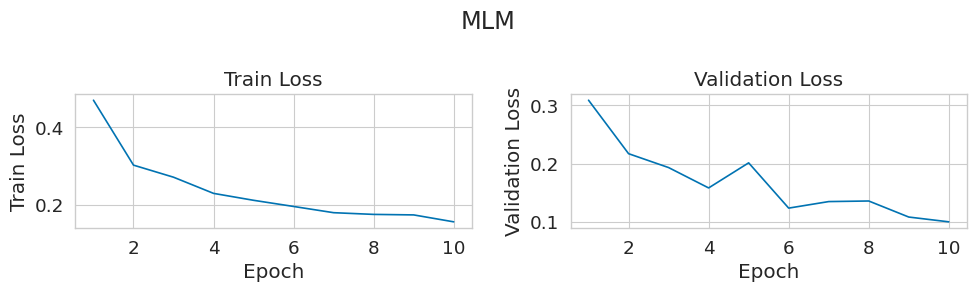

In [ ]:
mlm_train_loss, mlm_val_loss = train_mlm(model, mlm_train_loader, mlm_val_loader, device,
                                            mse_based=True, epochs=10, lr=5e-4, weight_decay=1e-2, tune_lr=True, 
                                            save_folder="ckp/MLM/", id="Flux", use_multiple_gpu=False)
plot_training_vs_validation_losses(mlm_train_loss, mlm_val_loss, "MLM")

In [5]:
importlib.reload(config)
model.load_state_dict(torch.load(config.MLM_FLUX_CKP))
print(f"Model loaded from checkpoint: {config.MLM_FLUX_CKP}")
val_loss = evaluate_mlm(model, mlm_val_loader, mask_token=-1, mse_based=True, device=device)
print(f"Validation Loss: {val_loss:.4f}")

Model loaded from checkpoint: ckp/MLM/MLM_Flux_ValLoss0.1001.pth


Evaluating MLM:   0%|          | 0/63 [00:00<?, ?it/s]

Validation Loss: 0.1008


In [55]:
importlib.reload(config)
fold_results = train_cls("Flux", model_config, 
                        labelled_dataset, k_folds=5, batch_size=32, 
                        epochs=15, lr=1e-3, weight_decay=0,
                        use_mlm=True, mlm_path="ckp/MLM/MLM_Flux_ValLoss0.1001.pth", save_path="ckp/CLS", 
                        device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results]):.4f}")

Fold 1/5
Positive weight: 0.439
Epoch 1/15, Loss: (0.4842 | 0.5560), Model AUC: (0.8015 | 0.7812), Precision: 0.8657, Recall: 0.6679, F1: 0.7540, Acc: 0.6965 | lr: 0.001
Epoch 2/15, Loss: (0.4341 | 0.5663), Model AUC: (0.8289 | 0.7957), Precision: 0.8667, Recall: 0.6964, F1: 0.7723, Acc: 0.7139 | lr: 0.001
Epoch 3/15, Loss: (0.4191 | 0.4937), Model AUC: (0.8370 | 0.8071), Precision: 0.8560, Recall: 0.7857, F1: 0.8194, Acc: 0.7587 | lr: 0.001
Epoch 4/15, Loss: (0.4178 | 0.5939), Model AUC: (0.8366 | 0.8033), Precision: 0.8773, Recall: 0.6893, F1: 0.7720, Acc: 0.7164 | lr: 0.001
Epoch 5/15, Loss: (0.4208 | 0.4966), Model AUC: (0.8394 | 0.8092), Precision: 0.8615, Recall: 0.8000, F1: 0.8296, Acc: 0.7711 | lr: 0.001
Epoch 6/15, Loss: (0.4072 | 0.5206), Model AUC: (0.8376 | 0.8065), Precision: 0.8787, Recall: 0.7500, F1: 0.8092, Acc: 0.7537 | lr: 0.001
Epoch 7/15, Loss: (0.3987 | 0.4987), Model AUC: (0.8433 | 0.8091), Precision: 0.8599, Recall: 0.7893, F1: 0.8231, Acc: 0.7637 | lr: 0.001
Ep

In [65]:
fold_results_nomlm = train_cls("Flux", model_config, 
                            labelled_dataset, k_folds=5, batch_size=32, 
                            epochs=15, lr=1e-3, weight_decay=0,
                            use_mlm=False, mlm_path=None, save_path="ckp/CLS", 
                            device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results_nomlm]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results_nomlm]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results_nomlm]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f}")

Fold 1/5
Positive weight: 0.439
Epoch 1/15, Loss: (0.5604 | 0.6092), Model AUC: (0.6754 | 0.6931), Precision: 0.6965, Recall: 1.0000, F1: 0.8211, Acc: 0.6965 | lr: 0.001
Epoch 2/15, Loss: (0.5497 | 0.6884), Model AUC: (0.6861 | 0.7023), Precision: 0.7879, Recall: 0.4643, F1: 0.5843, Acc: 0.5398 | lr: 0.001
Epoch 3/15, Loss: (0.5502 | 0.5859), Model AUC: (0.7016 | 0.7205), Precision: 0.6965, Recall: 1.0000, F1: 0.8211, Acc: 0.6965 | lr: 0.001
Epoch 4/15, Loss: (0.5065 | 0.6246), Model AUC: (0.7297 | 0.7347), Precision: 0.8315, Recall: 0.5286, F1: 0.6463, Acc: 0.5970 | lr: 0.001
Epoch 5/15, Loss: (0.4448 | 0.5581), Model AUC: (0.8210 | 0.7887), Precision: 0.8543, Recall: 0.7536, F1: 0.8008, Acc: 0.7388 | lr: 0.001
Epoch 6/15, Loss: (0.4645 | 0.5591), Model AUC: (0.7151 | 0.6904), Precision: 0.7206, Recall: 0.9857, F1: 0.8326, Acc: 0.7239 | lr: 0.001
Epoch 7/15, Loss: (0.4632 | 0.5733), Model AUC: (0.7604 | 0.7042), Precision: 0.8368, Recall: 0.7143, F1: 0.7707, Acc: 0.7040 | lr: 0.001
Ep

In [5]:
# with open('objects/flux_fold_results_mlm_last_l_conc.pkl', 'wb') as f:
#     pickle.dump(fold_results, f)
# with open('objects/flux_fold_results_nomlm_last_l_conc.pkl', 'wb') as f:
#     pickle.dump(fold_results_nomlm, f)

with open('objects/flux_fold_results_mlm_last_l_conc.pkl', 'rb') as f:
    fold_results = pickle.load(f)
with open('objects/flux_fold_results_nomlm_last_l_conc.pkl', 'rb') as f:
        fold_results_nomlm = pickle.load(f)

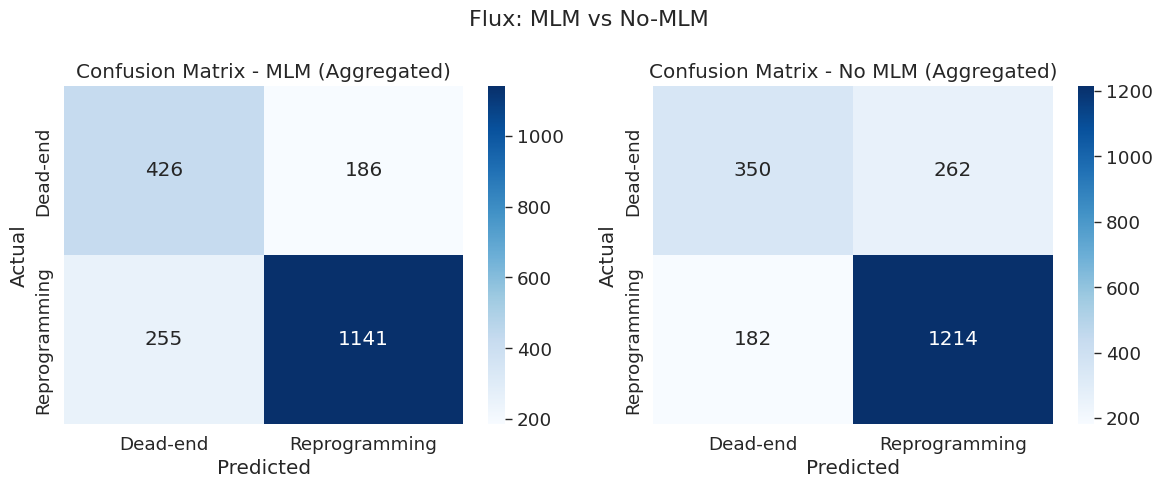

In [6]:
cms_mlm = compute_confusion_matrices("Flux", model_config, fold_results, labelled_dataset, device)
cms_nomlm = compute_confusion_matrices("Flux", model_config, fold_results_nomlm, labelled_dataset, device)
plot_conf_matrix_mlm_vs_nomlm(cms_mlm, cms_nomlm, m_type="Flux", only_agg=True, suptitle="Flux: MLM vs No-MLM")

In [7]:
# compute mean and std of train_auc and best_val_auc keys in fold_results and fold_results_nomlm
train_auc_mlm = np.mean([fr['train_auc'] for fr in fold_results])
train_auc_nomlm = np.mean([fr['train_auc'] for fr in fold_results_nomlm])
train_auc_mlm_std = np.std([fr['train_auc'] for fr in fold_results])
train_auc_nomlm_std = np.std([fr['train_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm = np.mean([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm = np.mean([fr['best_val_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm_std = np.std([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm_std = np.std([fr['best_val_auc'] for fr in fold_results_nomlm])

print(f"Train AUC: MLM: {train_auc_mlm:.4f} ± {train_auc_mlm_std:.4f}, No-MLM: {train_auc_nomlm:.4f} ± {train_auc_nomlm_std:.4f}")
print(f"Best Val AUC: MLM: {best_val_auc_mlm:.4f} ± {best_val_auc_mlm_std:.4f}, No-MLM: {best_val_auc_nomlm:.4f} ± {best_val_auc_nomlm_std:.4f}")

Train AUC: MLM: 0.8464 ± 0.0116, No-MLM: 0.8217 ± 0.0133
Best Val AUC: MLM: 0.8357 ± 0.0164, No-MLM: 0.8171 ± 0.0205


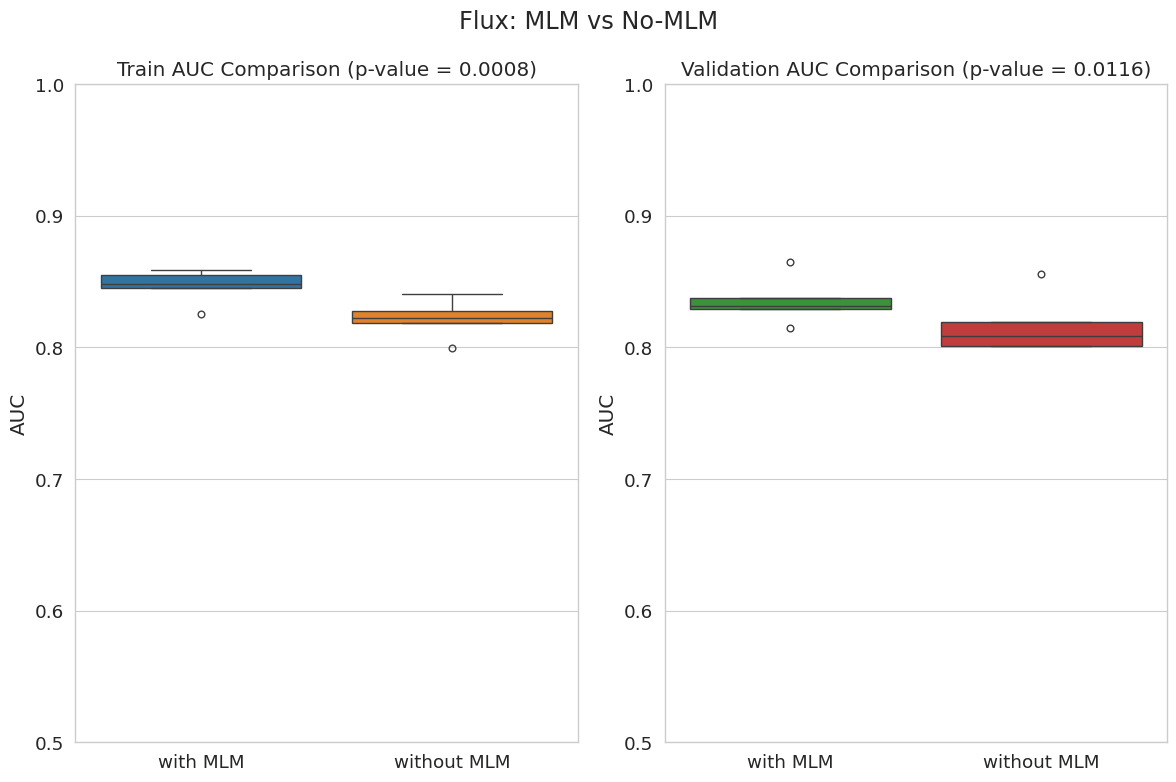

In [8]:
plot_auc_boxplot_comparison(fold_results, fold_results_nomlm, title="Flux: MLM vs No-MLM")

In [9]:
metrics_mlm = compute_metrics_from_confusion_matrix(cms_mlm[:-1])
metrics_nomlm = compute_metrics_from_confusion_matrix(cms_nomlm[:-1])

avg_mlm = metrics_mlm["average"]
std_mlm = metrics_mlm["std"]
avg_nomlm = metrics_nomlm["average"]
std_nomlm = metrics_nomlm["std"]

print("Flux: MLM")
for k, v in avg_mlm.items():
    print(f"{k}: {v:.4f} ± {std_mlm[k]:.4f}")
print("\nFlux: No-MLM")
for k, v in avg_nomlm.items():
    print(f"{k}: {v:.4f} ± {std_nomlm[k]:.4f}")

Flux: MLM
precision: 0.8586 ± 0.0306
recall: 0.8093 ± 0.0588
f1: 0.8308 ± 0.0157
accuracy: 0.7723 ± 0.0105

Flux: No-MLM
precision: 0.8268 ± 0.0454
recall: 0.8496 ± 0.0472
f1: 0.8355 ± 0.0048
accuracy: 0.7673 ± 0.0175


In [10]:
# print each fold best val auc separate based on mlm and no mlm 5 folds for each)
for i in range(5):
    print(f"Fold {i+1}: MLM: {fold_results[i]['best_val_auc']:.4f}, No-MLM: {fold_results_nomlm[i]['best_val_auc']:.4f}")
print(f"val auc mlm: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}")
print(f"val auc no mlm: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}")
# compute p-value for mlm and no-mlm values for val auc
from scipy.stats import ttest_rel
print("p-value for val auc: ", ttest_rel([fr['best_val_auc'] for fr in fold_results], [fr['best_val_auc'] for fr in fold_results_nomlm]))


Fold 1: MLM: 0.8149, No-MLM: 0.8009
Fold 2: MLM: 0.8376, No-MLM: 0.8087
Fold 3: MLM: 0.8294, No-MLM: 0.8008
Fold 4: MLM: 0.8317, No-MLM: 0.8192
Fold 5: MLM: 0.8648, No-MLM: 0.8557
val auc mlm: 0.8357 ± 0.0164
val auc no mlm: 0.8171 ± 0.0205
p-value for val auc:  TtestResult(statistic=4.415140318716906, pvalue=0.011554390981813491, df=4)


Evaluating Classifier: 0it [00:00, ?it/s]

['(0.8009 | 0.8009)', '(0.8087 | 0.8087)', '(0.8008 | 0.8008)', '(0.8192 | 0.8192)', '(0.8557 | 0.8557)']


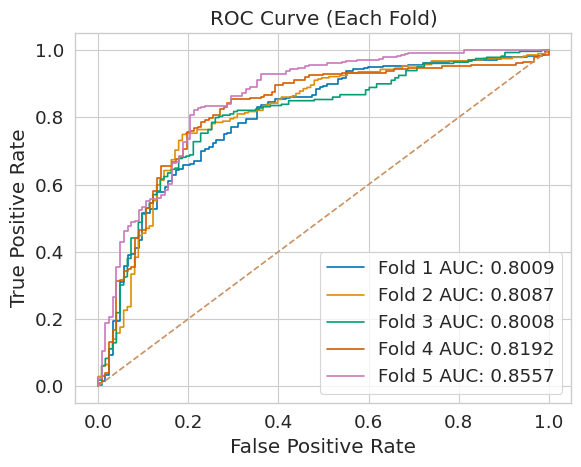

In [11]:
aucs_stored, aucs, val_preds, val_labels = evaluate_cls_cv("Flux", fold_results_nomlm, model_config, labelled_dataset, device)
print([f"({a:.4f} | {b:.4f})" for a,b in zip(aucs_stored, aucs)])
plot_roc_auc_curve(val_preds, val_labels, m_type="Flux", aggregate=False)

In [12]:
import json
data_to_store = {
    "modality": "Flux",
    "val_preds": [val_preds[i].tolist() for i in range(5)],
    "val_labels": [val_labels[i].tolist() for i in range(5)]
}
with open('objects/Flux_val_preds.json', 'w') as f:
    json.dump(data_to_store, fp=f)

## Plot Similarity Heatmap

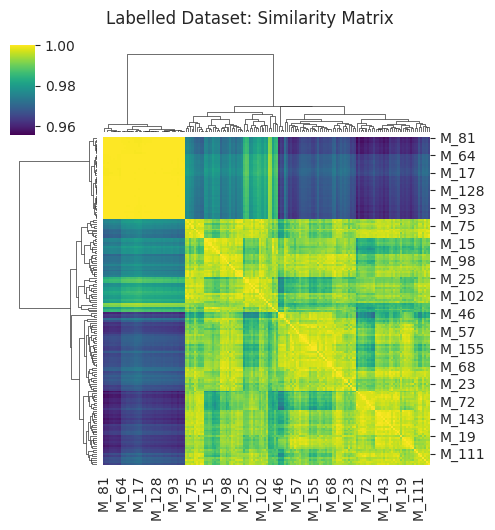

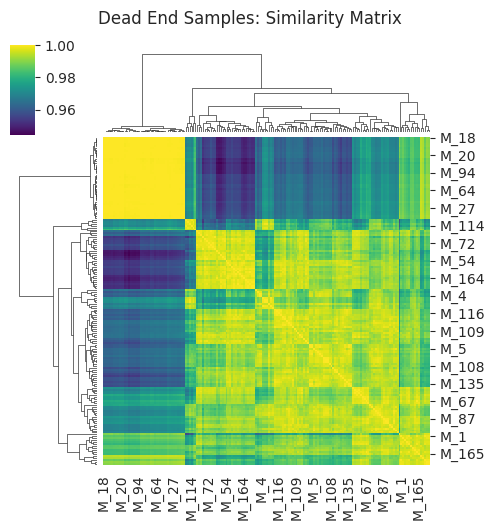

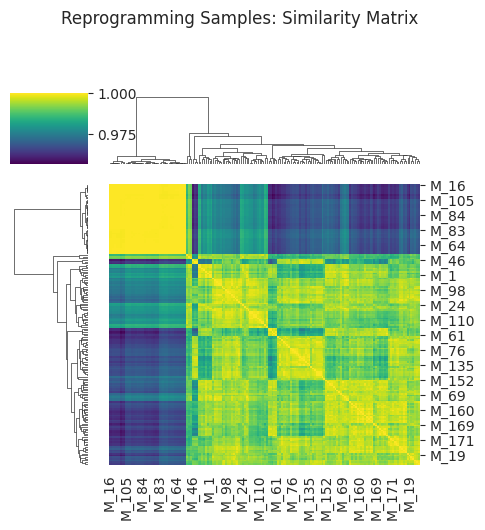

In [24]:
# Compute Similarity Matrix
dead_end_ds, repro_ds = separate_dataset(labelled_dataset)

model = SingleTransformer(id="Flux", **model_config).to(device)
model.load_state_dict(torch.load(config.MLM_FLUX_CKP))

sm_labelled = compute_similarity_matrix(model, labelled_dataset, device)
sm_dead_end = compute_similarity_matrix(model, dead_end_ds, device)
sm_repro = compute_similarity_matrix(model, repro_ds, device)

# Create clustermap for Labelled Dataset
df_labelled = pd.DataFrame(sm_labelled, index=flux_names, columns=flux_names)
g1 = sns.clustermap(df_labelled, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g1.fig.suptitle("Labelled Dataset: Similarity Matrix", y=1.05)

# Create clustermap for Dead End Dataset
df_dead_end = pd.DataFrame(sm_dead_end, index=flux_names, columns=flux_names)
g2 = sns.clustermap(df_dead_end, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g2.fig.suptitle("Dead End Samples: Similarity Matrix", y=1.05)

# Create clustermap for Reproducible Dataset
df_repro = pd.DataFrame(sm_repro, index=flux_names, columns=flux_names)
g3 = sns.clustermap(df_repro, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g3.fig.suptitle("Reprogramming Samples: Similarity Matrix", y=1.05)

plt.tight_layout()
plt.show()

## Analyse Wrong Predictions

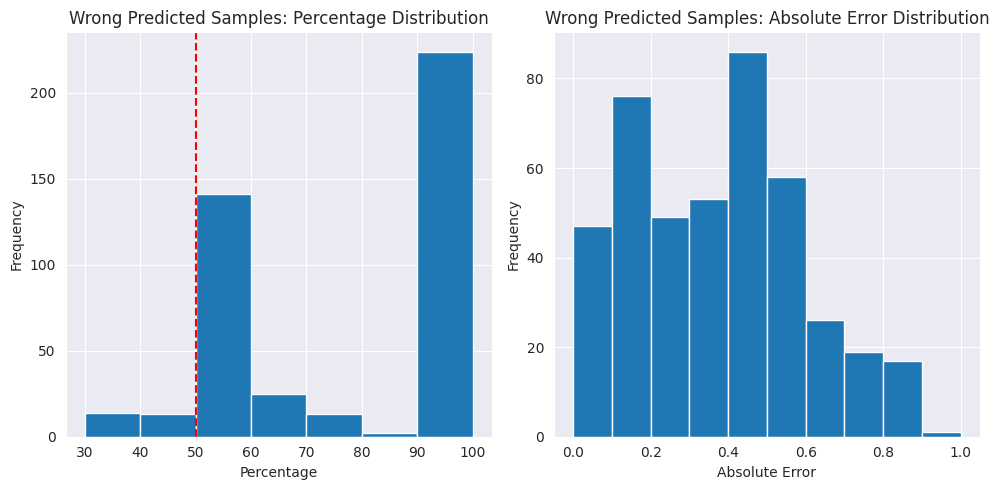

In [25]:
# get valid indices from val_index of fold_results
val_indices = [fr['val_idx'] for fr in fold_results]
# get wrong predicted samples from val_preds and val_labels and val_indices
wrong_preds = []
wrong_indices = []
for p, g, i in zip(np.concatenate(val_preds), np.concatenate(val_labels), np.concatenate(val_indices)):
    if p.round() != g:
        wrong_preds.append(p)
        wrong_indices.append(i)
wrong_pcts = pcts[wrong_indices].numpy().tolist()

# plot wrong_pcts with 10 period bins histogram and plot abs(1- wrong_preds) histogram with 0.1 period bins 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.hist(wrong_pcts, bins=7, range=(30, 100))
ax1.axvline(x=50, color='red', linestyle='--')
ax1.set_title("Wrong Predicted Samples: Percentage Distribution")
ax1.set_xlabel("Percentage")
ax1.set_ylabel("Frequency")

ax2.hist(np.abs(1 - np.array(wrong_preds)), bins=10, range=(0, 1))
ax2.set_title("Wrong Predicted Samples: Absolute Error Distribution")
ax2.set_xlabel("Absolute Error")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# # get indices of top 30 wrong predicted samples with highest absolute error
# top_30_wrong_indices = np.argsort(np.abs(1 - np.array(wrong_preds)))[-30:]
# top_30_wrong_pcts = pcts[wrong_indices][top_30_wrong_indices].numpy().tolist()

# # plot top_30_wrong_pcts with 10 period bins histogram and plot abs(1- wrong_preds) histogram with 0.1 period bins
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# ax1.hist(top_30_wrong_pcts, bins=7, range=(30, 100))
# ax1.axvline(x=50, color='red', linestyle='--')
# ax1.set_title("Top 30 Wrong Predicted Samples: Percentage Distribution")
# ax1.set_xlabel("Percentage")
# ax1.set_ylabel("Frequency")

# ax2.hist(np.abs(1 - np.array(wrong_preds))[top_30_wrong_indices], bins=10, range=(0, 1))
# ax2.set_title("Top 30 Wrong Predicted Samples: Absolute Error Distribution")
# ax2.set_xlabel("Absolute Error")
# ax2.set_ylabel("Frequency")

# plt.tight_layout()
# plt.show()

## Plot Latent Space (CLS Token Embeddings)

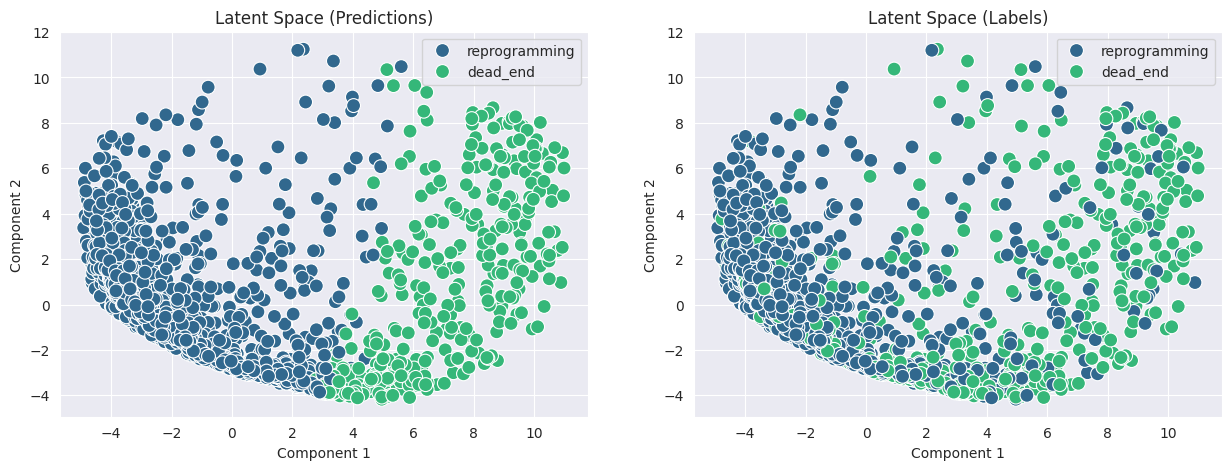

In [26]:
ls, labels, preds = get_latent_space("Flux", fold_results, labelled_dataset, model_config, device)

pca = PCA(n_components=2)
reduced_latent_space = pca.fit_transform(ls)

labels_str = ['reprogramming' if l == 1 else 'dead_end' for l in labels]
preds_str = ['reprogramming' if l == 1 else 'dead_end' for l in preds]
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=reduced_latent_space[:, 0], y=reduced_latent_space[:, 1], hue=preds_str, palette="viridis", s=100)
plt.title('Latent Space (Predictions)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.subplot(1, 2, 2)
sns.scatterplot(x=reduced_latent_space[:, 0], y=reduced_latent_space[:, 1], hue=labels_str, palette="viridis", s=100)
plt.title('Latent Space (Labels)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

## Analyse Shift in Latent Space

In [27]:
feature_importance = analyze_feature_importance("Flux", model_config, fold_results, labelled_dataset, flux_names, device, perturbation_scale=0.1)

100%|██████████| 168/168 [00:32<00:00,  5.11it/s]


M_23: 0.24143514037132263
M_15: 0.048609212040901184
M_91: 0.045262835919857025
M_114: 0.034564148634672165
M_69: 0.033234503120183945
M_50: 0.02984866313636303
M_54: 0.028392933309078217
M_106: 0.027133597061038017
M_92: 0.022240152582526207
M_124: 0.022043665871024132
M_38: 0.021243520081043243
M_4: 0.020497648045420647
M_150: 0.018710823729634285
M_46: 0.01862514577805996
M_164: 0.018211964517831802
M_48: 0.017765896394848824
M_3: 0.01756889559328556
M_145: 0.017472058534622192
M_166: 0.01706174947321415
M_162: 0.016016053035855293


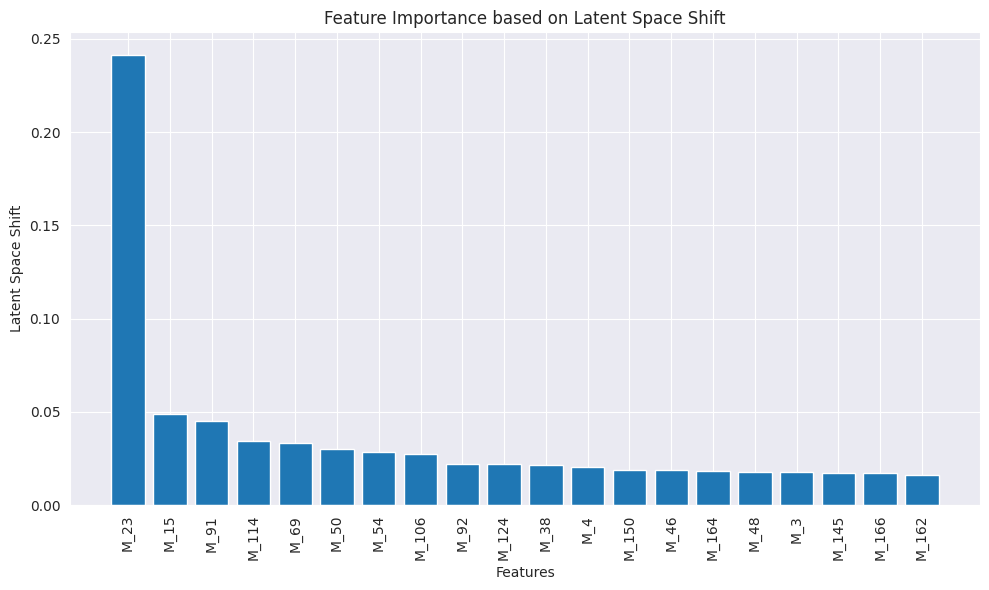

In [28]:
for feature, shift in feature_importance[:20]:
    print(f"{feature}: {shift}")

top_features = feature_importance[:20]
plt.figure(figsize=(10, 6))
plt.bar([f[0] for f in top_features], [f[1] for f in top_features])
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Latent Space Shift')

plt.title('Feature Importance based on Latent Space Shift')
plt.tight_layout()
plt.show()

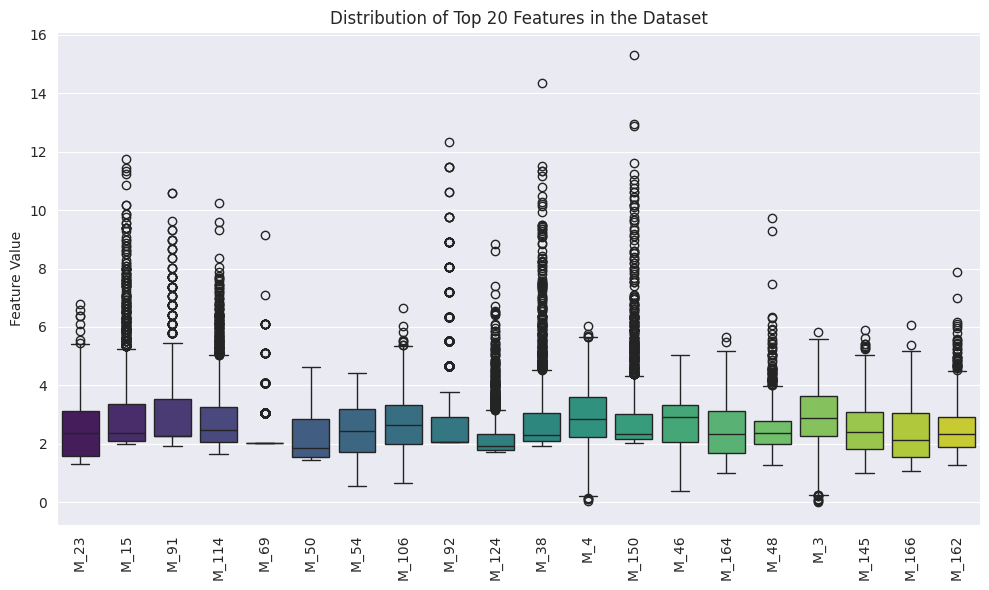

In [29]:
# plot the distribution of the top 20 features in the dataset
top_features_names = [f[0] for f in top_features]
top_features_indices = [flux_names.index(f) for f in top_features_names]
top_features_data = labelled_dataset.tensors[0][:, top_features_indices].numpy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_features_data, palette="viridis")
plt.xticks(range(20), top_features_names, rotation=90)
plt.ylabel('Feature Value')
plt.title('Distribution of Top 20 Features in the Dataset')
plt.tight_layout()
plt.show()

In [32]:
import shap
import torch.nn as nn

In [43]:
class SingleTransformerWrapper(nn.Module):
    def __init__(self, model):
        super(SingleTransformerWrapper, self).__init__()
        self.model = model

    def forward(self, *x):
        # Split inputs if necessary
        x_data, batch_indices = x
        batch_indices = batch_indices.long()
        preds, _ = self.model(x_data, batch_indices)
        return preds

In [49]:
shap_values_all_folds = []
for fold_result in fold_results:
    model = SingleTransformer(id="Flux", **model_config).to(device)
    model.load_state_dict(torch.load(fold_result['best_model_path']))
    model.eval()
    wrapped_model = SingleTransformerWrapper(model).to(device)

    x, batch_indices, _ = labelled_dataset.tensors
    x = x.to(device).float()
    batch_indices = batch_indices.to(device).float()
    background_data = [x[:100], batch_indices[:100]]


    explainer = shap.DeepExplainer(wrapped_model, background_data)
    shap_values = explainer.shap_values([x, batch_indices])

    shap_values_all_folds.append(shap_values)


shap_values_all_folds = np.array(shap_values_all_folds)
shap_values_mean = np.mean(shap_values_all_folds, axis=0)


RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.

In [ ]:

shap.summary_plot(shap_values_mean, x, feature_names=flux_names, plot_type='bar', max_display=20)

In [25]:
type(labelled_dataset.tensors)

tuple

In [ ]:
# compute shap values for the model to see the feature importance
import shap
shap.initjs()

shap_values = []

for fold_result in fold_results:
    model = SingleTransformer(id="Flux", **model_config).to(device)
    model.load_state_dict(torch.load(fold_result['model_path']))
    explainer = shap.Explainer(model, labelled_dataset.tensors[0])
    shap_values.append(explainer(labelled_dataset.tensors[0]))

shap_values = np.array([sv.values for sv in shap_values])
shap_values = shap_values.mean(axis=0)

shap.summary_plot(shap_values, labelled_dataset.tensors[0], feature_names=flux_names, plot_type='bar', max_display=20)
